In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_camp_table = pd.read_csv("../dunnhumby_The-Complete-Journey/campaign_table.csv")
df_camp_desc = pd.read_csv("../dunnhumby_The-Complete-Journey/campaign_desc.csv")
df_coupon_red = pd.read_csv("../dunnhumby_The-Complete-Journey/coupon_redempt.csv")
df_coupon = pd.read_csv("../dunnhumby_The-Complete-Journey/coupon.csv")
df_trxn = pd.read_csv("../dunnhumby_The-Complete-Journey/transaction_data.csv")
df_product = pd.read_csv("../dunnhumby_The-Complete-Journey/product.csv")
df_segmented = pd.read_csv("../dunnhumby_The-Complete-Journey/segmented_df.csv")

In [3]:
df_camp_table.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [4]:
count_camps_per_hsld = df_camp_table.groupby('household_key')['CAMPAIGN'].count().reset_index()
count_camps_per_hsld.rename(columns={'CAMPAIGN': 'count_per_hsld'}, inplace=True)
count_camps_per_hsld.head(10)

,household_key,count_per_hsld
0,1,8
1,2,1
2,3,3
3,4,1
4,6,4
5,7,4
6,8,10
7,13,10
8,14,5
9,16,2


In [5]:
count_camps_per_hsld.shape

(1584, 2)

In [6]:
tab2 =df_trxn.groupby('household_key')['BASKET_ID'].nunique().reset_index()

In [7]:
tab2.head()

,household_key,BASKET_ID
0,1,86
1,2,45
2,3,47
3,4,30
4,5,40


In [8]:
hh_camp_mapping = pd.merge(left = tab2, right=count_camps_per_hsld, how='left', on='household_key').fillna(0).drop(columns=['BASKET_ID'])
hh_camp_mapping.head(10)

,household_key,count_per_hsld
0,1,8.0
1,2,1.0
2,3,3.0
3,4,1.0
4,5,0.0
5,6,4.0
6,7,4.0
7,8,10.0
8,9,0.0
9,10,0.0


In [9]:
hh_camp_mapping.shape

(2500, 2)

In [10]:
df_coupon_red.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [11]:
df_coupon_red.duplicated().sum()

np.int64(0)

In [12]:
coupon_red_1 = df_coupon_red.loc[:,['household_key','CAMPAIGN']]

In [13]:
coupon_red_2 = coupon_red_1.drop_duplicates().groupby('household_key')['CAMPAIGN'].count().reset_index()
coupon_red_2.rename(columns={'CAMPAIGN': 'distinct_count_per_hsld'}, inplace=True)

In [14]:
coupon_red_2.head()

,household_key,distinct_count_per_hsld
0,1,2
1,8,1
2,13,7
3,14,1
4,18,3


In [15]:
hh_camp_mapping.head()

,household_key,count_per_hsld
0,1,8.0
1,2,1.0
2,3,3.0
3,4,1.0
4,5,0.0


In [16]:
no_of_camps_per_hsld =hh_camp_mapping.groupby('count_per_hsld').count().reset_index()

In [17]:
no_of_camps_per_hsld.head()

,count_per_hsld,household_key
0,0.0,916
1,1.0,268
2,2.0,224
3,3.0,214
4,4.0,169


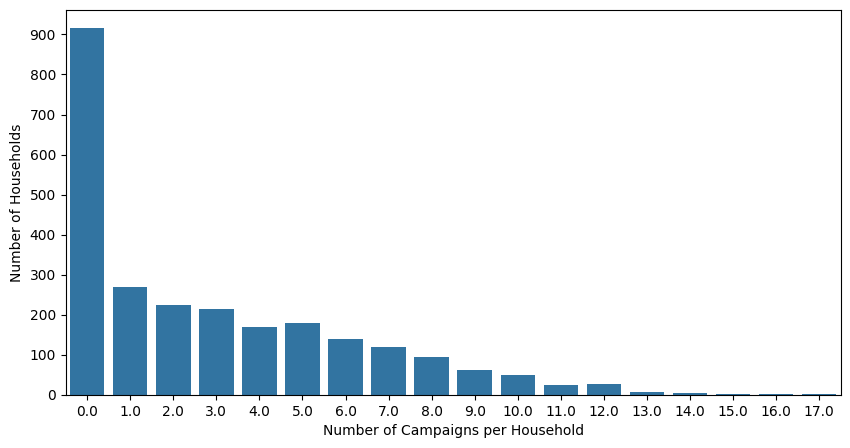

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x=no_of_camps_per_hsld['count_per_hsld'], y=no_of_camps_per_hsld['household_key'], data=no_of_camps_per_hsld)
plt.xlabel('Number of Campaigns per Household')
plt.ylabel('Number of Households')
plt.yticks(np.arange(0, 1000, 100))
plt.show()

In [19]:
coupon_red_2.head()

,household_key,distinct_count_per_hsld
0,1,2
1,8,1
2,13,7
3,14,1
4,18,3


In [20]:
camp_rdmptn_rate=pd.merge(hh_camp_mapping,coupon_red_2,on='household_key',how='outer').fillna(0)

In [21]:
camp_rdmptn_rate.head()

,household_key,count_per_hsld,distinct_count_per_hsld
0,1,8.0,2.0
1,2,1.0,0.0
2,3,3.0,0.0
3,4,1.0,0.0
4,5,0.0,0.0


In [22]:
camp_rdmptn_rate['camp_rdmptn_rate']=camp_rdmptn_rate['distinct_count_per_hsld']/camp_rdmptn_rate['count_per_hsld']
camp_rdmptn_rate.sort_values(['distinct_count_per_hsld','count_per_hsld'],ascending=False).head(30)

,household_key,count_per_hsld,distinct_count_per_hsld,camp_rdmptn_rate
255,256,12.0,10.0,0.833333
366,367,9.0,9.0,1.000000
978,979,13.0,8.0,0.615385
888,889,12.0,8.0,0.666667
981,982,14.0,7.0,0.500000
2279,2280,13.0,7.0,0.538462
12,13,10.0,7.0,0.700000
463,464,10.0,7.0,0.700000
2450,2451,9.0,7.0,0.777778
21,22,8.0,7.0,0.875000


In [23]:
camp_rdmptn_rate.isnull().sum()

household_key                0
count_per_hsld               0
distinct_count_per_hsld      0
camp_rdmptn_rate           916
dtype: int64

In [24]:
camp_rdmptn_rate.fillna(0,inplace=True)

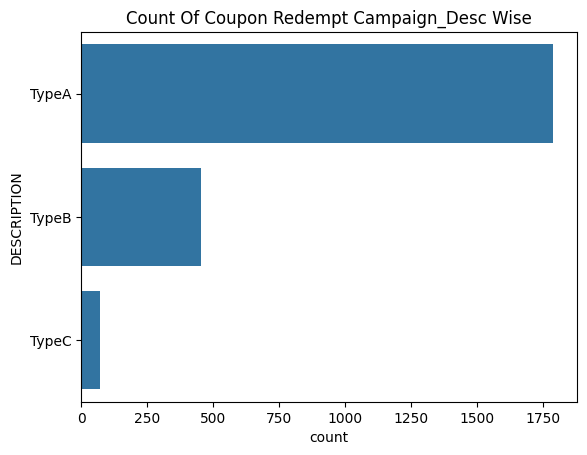

In [25]:
cpnrdmpt_campwise=pd.merge(df_camp_desc.loc[:,['DESCRIPTION','CAMPAIGN']],df_coupon_red.loc[:,['household_key','CAMPAIGN']],on='CAMPAIGN')
cpnrdmpt_campwise.groupby('DESCRIPTION')['household_key'].count()

sns.countplot(cpnrdmpt_campwise.DESCRIPTION.sort_values())
plt.title('Count of coupon redempt campaign_desc wise'.title())
plt.show()

**CREATION OF OUR DATASET**

In [26]:
df_coupon.head()

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [27]:
df_coupon.shape

(124548, 3)

In [28]:
df_coupon_red.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [29]:
df_coupon_red.shape

(2318, 4)

In [30]:
df_camp_table.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [31]:
pd.set_option('display.max_rows', None)

In [32]:
init = pd.DataFrame(np.arange(1,2501),columns=['household_key'])
init.head()

,household_key
0,1
1,2
2,3
3,4
4,5


In [33]:
init2 = pd.merge(init,df_camp_table, how='left', on='household_key').sort_values(['household_key','CAMPAIGN']).reset_index(drop=True)
init2.head(12)

,household_key,DESCRIPTION,CAMPAIGN
0,1,TypeA,8.0
1,1,TypeB,12.0
2,1,TypeA,13.0
3,1,TypeA,18.0
4,1,TypeC,20.0
5,1,TypeB,22.0
6,1,TypeB,23.0
7,1,TypeB,29.0
8,2,TypeA,18.0
9,3,TypeA,8.0


In [34]:
pd.merge(init,df_camp_table, how='left', on='household_key').isnull().sum()

household_key      0
DESCRIPTION      916
CAMPAIGN         916
dtype: int64

**CAMPAIGN EFFECTIVENESS**

In [35]:
a = df_camp_desc.merge(df_coupon_red, how='left', on='CAMPAIGN')
a = a.groupby('CAMPAIGN')['COUPON_UPC'].nunique().reset_index()

In [36]:
b = df_coupon.groupby('CAMPAIGN')['COUPON_UPC'].nunique().reset_index()

In [37]:
coupon_redempt_count_table = a.merge(b, how='left', on='CAMPAIGN').rename(columns={'COUPON_UPC_x':'COUPON_REDEMPT_COUNT','COUPON_UPC_y':'COUPON_COUNT'})
coupon_redempt_count_table['COUPON_REDEMPT_RATE'] = coupon_redempt_count_table['COUPON_REDEMPT_COUNT']/coupon_redempt_count_table['COUPON_COUNT']
coupon_redempt_count_table

,CAMPAIGN,COUPON_REDEMPT_COUNT,COUPON_COUNT,COUPON_REDEMPT_RATE
0,1,1,11,0.090909
1,2,4,16,0.250000
2,3,2,34,0.058824
3,4,6,12,0.500000
4,5,5,11,0.454545
5,6,1,1,1.000000
6,7,5,8,0.625000
7,8,105,209,0.502392
8,9,14,18,0.777778
9,10,7,14,0.500000


In [38]:
df_trxn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [39]:
df_camp_table.groupby('CAMPAIGN')['household_key'].nunique().reset_index().sort_values('household_key',ascending=False)

,CAMPAIGN,household_key
17,18,1133
12,13,1077
7,8,1076
29,30,361
25,26,332
21,22,276
19,20,244
13,14,224
10,11,214
16,17,202


In [40]:
df_trxn.groupby('household_key')['BASKET_ID'].count().reset_index().sort_values('BASKET_ID',ascending=False).head()

,household_key,BASKET_ID
717,718,6851
2458,2459,6646
1608,1609,6625
1110,1111,6576
1452,1453,6561


In [41]:
df_camp_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DESCRIPTION    7208 non-null   object
 1   household_key  7208 non-null   int64 
 2   CAMPAIGN       7208 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 169.1+ KB


In [42]:
# Filter to only the 1584 households that are in campaigns
# No point carrying the other 916 households at all
hh_in_any_campaign = df_camp_table['household_key'].unique()

trxn_filtered = df_trxn[df_trxn['household_key'].isin(hh_in_any_campaign)].copy()

print(f"Rows after household filter: {len(trxn_filtered)}")
# Already much smaller than 2.5M

# Now aggregate to household × day level
# This is the key reduction step
trxn_agg = trxn_filtered.groupby(['household_key', 'DAY']).agg(daily_sales = ('SALES_VALUE', 'sum'),daily_qty = ('QUANTITY', 'sum')).reset_index()

print(f"Rows after aggregation: {len(trxn_agg)}")
# Roughly 200K rows — very manageable



Rows after household filter: 2291916
Rows after aggregation: 194134


In [43]:
trxn_filtered.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [44]:
trxn_agg.head()

,household_key,DAY,daily_sales,daily_qty
0,1,51,78.66,34
1,1,67,41.10,14
2,1,88,26.90,13
3,1,94,63.43,32
4,1,101,53.45,20


In [45]:
results = []

for _, camp_row in df_camp_desc.iterrows():
    
    campaign_id = camp_row['CAMPAIGN']
    camp_type   = camp_row['DESCRIPTION']
    start_day   = camp_row['START_DAY']
    end_day     = camp_row['END_DAY']
    last_day    = 719  # last day in dataset
    
    # Households in THIS specific campaign only
    hh_this_campaign = df_camp_table[df_camp_table['CAMPAIGN'] == campaign_id]['household_key'].tolist()
    
    # Filter pre-aggregated table to these households
    # This is a small slice — never touches 2.5M rows
    camp_txn = trxn_agg[trxn_agg['household_key'].isin(hh_this_campaign)]
    
    # Split into 3 periods
    pre    = camp_txn[camp_txn['DAY'] < start_day]
    during = camp_txn[(camp_txn['DAY'] >= start_day) & (camp_txn['DAY'] <= end_day)]
    post   = camp_txn[camp_txn['DAY'] > end_day]
    
    results.append({
        'campaign'       : campaign_id,
        'campaign_type'  : camp_type,
        'start_day'      : start_day,
        'end_day'        : end_day,
        'pre_camp_sales'      : pre['daily_sales'].sum(),
        'during_camp_sales'   : during['daily_sales'].sum(),
        'post_camp_sales'     : post['daily_sales'].sum(),
        'pre_camp_qty'        : pre['daily_qty'].sum(),
        'during_camp_qty'     : during['daily_qty'].sum(),
        'post_camp_qty'       : post['daily_qty'].sum(),
        'hh_count'       : len(hh_this_campaign)
    })

campaign_effectiveness = pd.DataFrame(results)
print(campaign_effectiveness.shape)  # Should be (30, 10)
campaign_effectiveness

(30, 11)


,campaign,campaign_type,start_day,end_day,pre_camp_sales,during_camp_sales,post_camp_sales,pre_camp_qty,during_camp_qty,post_camp_qty,hh_count
0,24,TypeB,659,719,711868.88,63603.65,0.00,20711260,2205645,0,100
1,15,TypeC,547,708,74535.90,20022.50,316.51,1418807,355942,133,17
2,25,TypeB,659,691,1514059.55,85434.39,48603.32,52185985,3023126,1599100,187
3,20,TypeC,615,685,1572509.23,215726.02,72429.52,51693997,7730134,2403360,244
4,23,TypeB,646,684,1381223.96,97895.84,63448.17,55650053,4370354,2492553,183
5,21,TypeB,624,656,455943.19,29945.72,45033.57,19169364,1282985,2054434,65
6,22,TypeB,624,656,1764171.05,107776.48,163200.88,63729050,3928622,6120448,276
7,18,TypeA,587,642,4706322.76,533268.61,625230.00,161632632,18290132,21708141,1133
8,19,TypeB,603,635,684993.06,47669.13,107067.77,23973913,1571402,3802038,130
9,17,TypeB,575,607,1113068.33,73959.72,240989.65,32031118,2346588,7282728,202


In [46]:
campaign_effectiveness['pre_camp_sales_avg'] = campaign_effectiveness['pre_camp_sales'] / campaign_effectiveness['start_day']
campaign_effectiveness['during_camp_sales_avg'] = campaign_effectiveness['during_camp_sales'] / (campaign_effectiveness['end_day'] - campaign_effectiveness['start_day'])
campaign_effectiveness['post_camp_sales_avg'] = campaign_effectiveness['post_camp_sales'] / (719 - campaign_effectiveness['end_day'])

campaign_effectiveness['pre_camp_qty_avg'] = campaign_effectiveness['pre_camp_qty'] / campaign_effectiveness['start_day']
campaign_effectiveness['during_camp_qty_avg'] = campaign_effectiveness['during_camp_qty'] / (campaign_effectiveness['end_day'] - campaign_effectiveness['start_day'])
campaign_effectiveness['post_camp_qty_avg'] = campaign_effectiveness['post_camp_qty'] / (719 - campaign_effectiveness['end_day'])
campaign_effectiveness

,campaign,campaign_type,start_day,end_day,pre_camp_sales,during_camp_sales,post_camp_sales,pre_camp_qty,during_camp_qty,post_camp_qty,hh_count,pre_camp_sales_avg,during_camp_sales_avg,post_camp_sales_avg,pre_camp_qty_avg,during_camp_qty_avg,post_camp_qty_avg
0,24,TypeB,659,719,711868.88,63603.65,0.00,20711260,2205645,0,100,1080.225918,1060.060833,NaN,31428.315630,36760.750000,NaN
1,15,TypeC,547,708,74535.90,20022.50,316.51,1418807,355942,133,17,136.263071,124.363354,28.773636,2593.797075,2210.819876,12.090909
2,25,TypeB,659,691,1514059.55,85434.39,48603.32,52185985,3023126,1599100,187,2297.510698,2669.824687,1735.832857,79189.658574,94472.687500,57110.714286
3,20,TypeC,615,685,1572509.23,215726.02,72429.52,51693997,7730134,2403360,244,2556.925577,3081.800286,2130.280000,84055.279675,110430.485714,70687.058824
4,23,TypeB,646,684,1381223.96,97895.84,63448.17,55650053,4370354,2492553,183,2138.117585,2576.206316,1812.804857,86145.592879,115009.315789,71215.800000
5,21,TypeB,624,656,455943.19,29945.72,45033.57,19169364,1282985,2054434,65,730.678189,935.803750,714.818571,30720.134615,40093.281250,32610.063492
6,22,TypeB,624,656,1764171.05,107776.48,163200.88,63729050,3928622,6120448,276,2827.197196,3368.015000,2590.490159,102129.887821,122769.437500,97149.968254
7,18,TypeA,587,642,4706322.76,533268.61,625230.00,161632632,18290132,21708141,1133,8017.585622,9695.792909,8119.870130,275353.717206,332547.854545,281923.909091
8,19,TypeB,603,635,684993.06,47669.13,107067.77,23973913,1571402,3802038,130,1135.975224,1489.660313,1274.616310,39757.733002,49106.312500,45262.357143
9,17,TypeB,575,607,1113068.33,73959.72,240989.65,32031118,2346588,7282728,202,1935.771009,2311.241250,2151.693304,55706.292174,73330.875000,65024.357143


In [47]:
campaign_effectiveness_refined = campaign_effectiveness.copy()
campaign_effectiveness_refined = campaign_effectiveness_refined.drop(['pre_camp_sales', 'during_camp_sales', 'post_camp_sales', 'pre_camp_qty', 
                                                                      'during_camp_qty', 'post_camp_qty', 'start_day', 'end_day', 'hh_count', 'campaign_type'], axis=1).fillna(0)
campaign_effectiveness_refined

,campaign,pre_camp_sales_avg,during_camp_sales_avg,post_camp_sales_avg,pre_camp_qty_avg,during_camp_qty_avg,post_camp_qty_avg
0,24,1080.225918,1060.060833,0.000000,31428.315630,36760.750000,0.000000
1,15,136.263071,124.363354,28.773636,2593.797075,2210.819876,12.090909
2,25,2297.510698,2669.824687,1735.832857,79189.658574,94472.687500,57110.714286
3,20,2556.925577,3081.800286,2130.280000,84055.279675,110430.485714,70687.058824
4,23,2138.117585,2576.206316,1812.804857,86145.592879,115009.315789,71215.800000
5,21,730.678189,935.803750,714.818571,30720.134615,40093.281250,32610.063492
6,22,2827.197196,3368.015000,2590.490159,102129.887821,122769.437500,97149.968254
7,18,8017.585622,9695.792909,8119.870130,275353.717206,332547.854545,281923.909091
8,19,1135.975224,1489.660313,1274.616310,39757.733002,49106.312500,45262.357143
9,17,1935.771009,2311.241250,2151.693304,55706.292174,73330.875000,65024.357143


In [48]:
campaign_effectiveness_refined['lift_sales_ratio'] = np.round(campaign_effectiveness_refined['during_camp_sales_avg'] / campaign_effectiveness_refined['pre_camp_sales_avg'], 2)
campaign_effectiveness_refined['lift_qty_ratio'] = np.round(campaign_effectiveness_refined['during_camp_qty_avg'] / campaign_effectiveness_refined['pre_camp_qty_avg'], 2)
campaign_effectiveness_refined.sort_values('campaign', ascending=True).reset_index(drop=True)

,campaign,pre_camp_sales_avg,during_camp_sales_avg,post_camp_sales_avg,pre_camp_qty_avg,during_camp_qty_avg,post_camp_qty_avg,lift_sales_ratio,lift_qty_ratio
0,1,84.901445,101.438919,91.965685,2675.320809,1672.243243,2362.755952,1.19,0.63
1,2,300.113561,362.350625,291.083065,4216.994302,5756.531250,5316.113095,1.21,1.37
2,3,136.545140,152.810000,135.119870,3280.893258,4723.892857,3531.156352,1.12,1.44
3,4,625.447796,828.803437,766.579778,28589.935484,40345.281250,35939.485714,1.33,1.41
4,5,1584.950106,2115.705882,1804.438474,60072.453581,89064.411765,82068.668831,1.33,1.48
5,6,746.553206,987.351875,829.408776,34616.167939,51255.750000,41976.952381,1.32,1.48
6,7,1668.195578,2175.484118,1863.624704,59263.520101,84425.500000,74999.240418,1.30,1.42
7,8,7146.213981,8808.110625,8045.728996,233067.058252,307476.645833,293798.065637,1.23,1.32
8,9,1196.586115,1491.102813,1486.838889,41093.110345,50075.187500,59036.805556,1.25,1.22
9,10,1213.014773,1391.233750,1360.121607,43697.816415,60348.843750,54086.531250,1.15,1.38


**Step 1 — Build the Household × Week Panel**


In [49]:
# Start with campaign-enrolled households only
# Merge campaign_table with campaign_desc to get dates
camp_full = df_camp_table.merge(df_camp_desc, on=['CAMPAIGN', 'DESCRIPTION'])

# Merge transactions with campaign info at household level
# Each household's transactions get tagged with their campaign(s)
txn_camp = df_trxn.merge(
    camp_full[['household_key', 'CAMPAIGN', 'DESCRIPTION', 
               'START_DAY', 'END_DAY']],
    on='household_key',
    how='inner'  # only enrolled households
)

# Aggregate to household × campaign × week level
panel = txn_camp.groupby(
    ['household_key', 'CAMPAIGN', 'DESCRIPTION', 
     'START_DAY', 'END_DAY', 'WEEK_NO']
).agg(
    sales    = ('SALES_VALUE', 'sum'),
    quantity = ('QUANTITY',    'sum')
).reset_index()

print(panel.shape)
panel.head(10)

(518359, 8)


,household_key,CAMPAIGN,DESCRIPTION,START_DAY,END_DAY,WEEK_NO,sales,quantity
0,1,8,TypeA,412,460,8,78.66,34
1,1,8,TypeA,412,460,10,41.10,14
2,1,8,TypeA,412,460,13,26.90,13
3,1,8,TypeA,412,460,14,63.43,32
4,1,8,TypeA,412,460,15,53.45,20
5,1,8,TypeA,412,460,16,26.76,11
6,1,8,TypeA,412,460,17,23.55,12
7,1,8,TypeA,412,460,19,110.34,43
8,1,8,TypeA,412,460,20,87.44,43
9,1,8,TypeA,412,460,22,73.32,32


**Step 2 — Add the Campaign Dummy Variable**

In [50]:
# Convert days to weeks for comparison
panel['camp_start_week'] = (panel['START_DAY'] / 7).apply(np.ceil).astype(int)
panel['camp_end_week']   = (panel['END_DAY']   / 7).apply(np.ceil).astype(int)

# in_campaign = 1 if this week falls within the campaign window
panel['in_campaign'] = (
    (panel['WEEK_NO'] >= panel['camp_start_week']) &
    (panel['WEEK_NO'] <= panel['camp_end_week'])
).astype(int)

# Period label for easier analysis
def label_period(row):
    if row['WEEK_NO'] < row['camp_start_week']:
        return 'pre'
    elif row['WEEK_NO'] <= row['camp_end_week']:
        return 'during'
    else:
        return 'post'

panel['period'] = panel.apply(label_period, axis=1)

print(panel['in_campaign'].value_counts())
print(panel['period'].value_counts())

in_campaign
0    477449
1     40910
Name: count, dtype: int64
period
pre       343780
post      133669
during     40910
Name: count, dtype: int64


In [51]:
panel.head()

,household_key,CAMPAIGN,DESCRIPTION,START_DAY,END_DAY,WEEK_NO,sales,quantity,camp_start_week,camp_end_week,in_campaign,period
0,1,8,TypeA,412,460,8,78.66,34,59,66,0,pre
1,1,8,TypeA,412,460,10,41.10,14,59,66,0,pre
2,1,8,TypeA,412,460,13,26.90,13,59,66,0,pre
3,1,8,TypeA,412,460,14,63.43,32,59,66,0,pre
4,1,8,TypeA,412,460,15,53.45,20,59,66,0,pre


In [63]:
panel.head()

,household_key,CAMPAIGN,DESCRIPTION,START_DAY,END_DAY,WEEK_NO,sales,quantity,camp_start_week,camp_end_week,in_campaign,period,weeks_from_start,in_campaign_lag,post_campaign,sales_mean_hh,sales_demean,qty_mean_hh,qty_demean
0,1,8,TypeA,412,460,8,78.66,34,59,66,0,pre,-51,0,0,63.678824,14.981176,29.367647,4.632353
1,1,8,TypeA,412,460,10,41.10,14,59,66,0,pre,-49,0,0,63.678824,-22.578824,29.367647,-15.367647
2,1,8,TypeA,412,460,13,26.90,13,59,66,0,pre,-46,0,0,63.678824,-36.778824,29.367647,-16.367647
3,1,8,TypeA,412,460,14,63.43,32,59,66,0,pre,-45,0,0,63.678824,-0.248824,29.367647,2.632353
4,1,8,TypeA,412,460,15,53.45,20,59,66,0,pre,-44,0,0,63.678824,-10.228824,29.367647,-9.367647


In [64]:
window.head(20)

,household_key,CAMPAIGN,DESCRIPTION,START_DAY,END_DAY,WEEK_NO,sales,quantity,camp_start_week,camp_end_week,in_campaign,period,weeks_from_start
33,1,8,TypeA,412,460,56,7.99,1,59,66,0,pre,-3
34,1,8,TypeA,412,460,58,88.20,47,59,66,0,pre,-1
35,1,8,TypeA,412,460,60,89.18,49,59,66,1,during,1
36,1,8,TypeA,412,460,61,82.84,40,59,66,1,during,2
37,1,8,TypeA,412,460,62,49.33,21,59,66,1,during,3
38,1,8,TypeA,412,460,63,137.88,59,59,66,1,during,4
39,1,8,TypeA,412,460,65,69.78,31,59,66,1,during,6
40,1,8,TypeA,412,460,67,68.81,29,59,66,0,post,8
107,1,12,TypeB,477,509,65,69.78,31,69,73,0,pre,-4
108,1,12,TypeB,477,509,67,68.81,29,69,73,0,pre,-2


**Step 3 — Find the Lag**  

Before running regression, find how many weeks after campaign start the spending actually peaks. This tells you what lag to use.

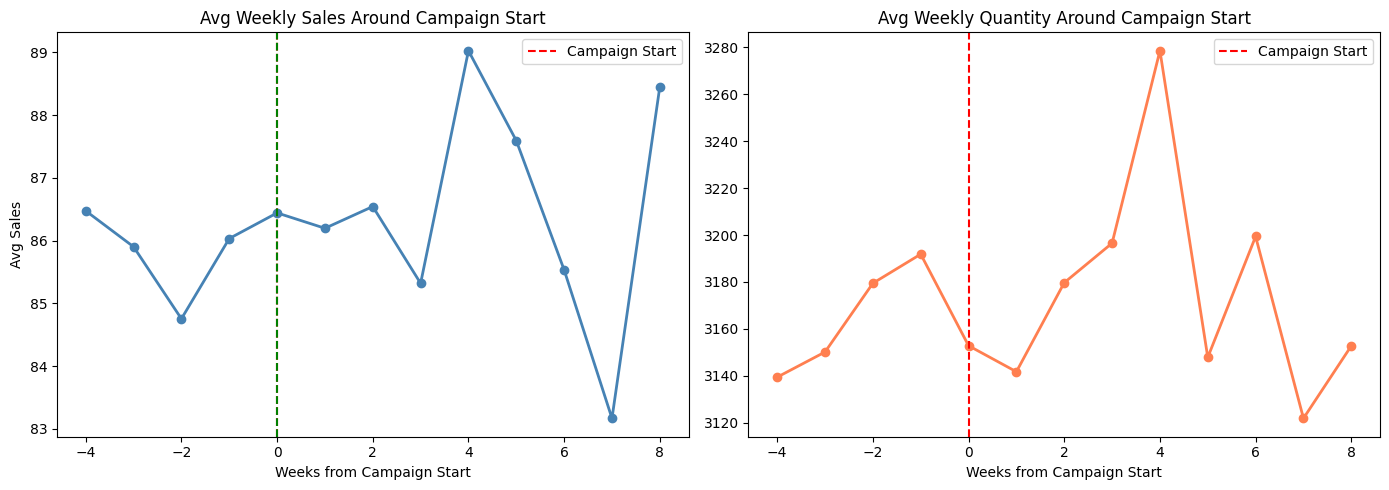

    weeks_from_start  avg_sales      avg_qty
0                 -4  86.474024  3139.429710
1                 -3  85.901683  3150.151650
2                 -2  84.754408  3179.449867
3                 -1  86.032944  3191.841364
4                  0  86.441398  3152.827988
5                  1  86.196506  3141.735210
6                  2  86.542793  3179.682892
7                  3  85.319396  3196.528108
8                  4  89.025075  3278.543838
9                  5  87.591940  3147.857143
10                 6  85.532987  3199.377577
11                 7  83.168686  3121.878976
12                 8  88.451949  3152.754416


In [66]:
import matplotlib.pyplot as plt

# For each campaign, look at average weekly sales 
# relative to campaign start week
panel['weeks_from_start'] = panel['WEEK_NO'] - panel['camp_start_week']

# Focus on window -4 to +8 weeks around campaign start
window = panel[panel['weeks_from_start'].between(-4, 8)]

lag_profile = window.groupby('weeks_from_start').agg(
    avg_sales = ('sales', 'mean'),
    avg_qty   = ('quantity', 'mean')
).reset_index()

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lag_profile['weeks_from_start'], 
             lag_profile['avg_sales'], 
             marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=0, color='red', linestyle='--', label='Campaign Start')
axes[0].axvline(x=0, color='green', linestyle='--')
axes[0].set_title('Avg Weekly Sales Around Campaign Start')
axes[0].set_xlabel('Weeks from Campaign Start')
axes[0].set_ylabel('Avg Sales')
axes[0].legend()

axes[1].plot(lag_profile['weeks_from_start'], 
             lag_profile['avg_qty'], 
             marker='o', color='coral', linewidth=2)
axes[1].axvline(x=0, color='red', linestyle='--', label='Campaign Start')
axes[1].set_title('Avg Weekly Quantity Around Campaign Start')
axes[1].set_xlabel('Weeks from Campaign Start')
axes[1].legend()

plt.tight_layout()
plt.show()

print(lag_profile)

**Step 4 — Add Lag Variable and Run Regression**

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf

# Both plots confirm peak at week +4
LAG = 4

panel = panel.sort_values(['household_key', 'CAMPAIGN', 'WEEK_NO'])

panel['in_campaign_lag'] = (
    panel.groupby(['household_key', 'CAMPAIGN'])['in_campaign']
    .shift(-LAG)
    .fillna(0)
    .astype(int)
)

# Also add a post-campaign flag to capture the pullback effect
panel['post_campaign'] = (
    panel['period'] == 'post'
).astype(int)

panel[['household_key', 'CAMPAIGN', 'WEEK_NO', 
             'in_campaign', 'in_campaign_lag', 
             'post_campaign', 'period']].head(20)

,household_key,CAMPAIGN,WEEK_NO,in_campaign,in_campaign_lag,post_campaign,period
0,1,8,8,0,0,0,pre
1,1,8,10,0,0,0,pre
2,1,8,13,0,0,0,pre
3,1,8,14,0,0,0,pre
4,1,8,15,0,0,0,pre
5,1,8,16,0,0,0,pre
6,1,8,17,0,0,0,pre
7,1,8,19,0,0,0,pre
8,1,8,20,0,0,0,pre
9,1,8,22,0,0,0,pre


In [54]:
import statsmodels.formula.api as smf

# Full model — immediate effect + lag effect + post-campaign pullback
model_full = smf.ols(
    formula='sales ~ in_campaign + in_campaign_lag + post_campaign',
    data=panel
).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     43.51
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           4.19e-28
Time:                        19:35:31   Log-Likelihood:            -2.9763e+06
No. Observations:              518359   AIC:                         5.953e+06
Df Residuals:                  518355   BIC:                         5.953e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          85.2360      0.132    6

**The Fix — Household Fixed Effects**

In [55]:
# Step 1 — Fix the duplication problem first
# Each household-week should appear once per campaign they're enrolled in
# but sales should not be duplicated

# Check how many times a household-week appears
dup_check = panel.groupby(
    ['household_key', 'WEEK_NO']
)['sales'].count()
print("Max times a hh-week appears:", dup_check.max())
print("Mean:", dup_check.mean().round(2))

Max times a hh-week appears: 17
Mean: 5.14


In [56]:
# Step 2 — Demean sales at the household level
# This removes each household's baseline spending level
panel['sales_mean_hh'] = panel.groupby(
    'household_key')['sales'].transform('mean')

panel['sales_demean'] = panel['sales'] - panel['sales_mean_hh']

# Same for quantity
panel['qty_mean_hh'] = panel.groupby(
    'household_key')['quantity'].transform('mean')

panel['qty_demean'] = panel['quantity'] - panel['qty_mean_hh']

print("Demeaned sales sample:")
print(panel[['household_key', 'WEEK_NO', 'sales', 
             'sales_mean_hh', 'sales_demean']].head(10))

Demeaned sales sample:
   household_key  WEEK_NO   sales  sales_mean_hh  sales_demean
0              1        8   78.66      63.678824     14.981176
1              1       10   41.10      63.678824    -22.578824
2              1       13   26.90      63.678824    -36.778824
3              1       14   63.43      63.678824     -0.248824
4              1       15   53.45      63.678824    -10.228824
5              1       16   26.76      63.678824    -36.918824
6              1       17   23.55      63.678824    -40.128824
7              1       19  110.34      63.678824     46.661176
8              1       20   87.44      63.678824     23.761176
9              1       22   73.32      63.678824      9.641176


In [57]:
# Step 3 — Rerun regression on demeaned sales
model_fe = smf.ols(
    formula='sales_demean ~ in_campaign + in_campaign_lag + post_campaign',
    data=panel
).fit()

print(model_fe.summary())

                            OLS Regression Results                            
Dep. Variable:           sales_demean   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     22.77
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           9.88e-15
Time:                        19:35:32   Log-Likelihood:            -2.8656e+06
No. Observations:              518359   AIC:                         5.731e+06
Df Residuals:                  518355   BIC:                         5.731e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.4936      0.107     

**Step 5 — Calculate Lift Per Campaign (The "Campaign = 0" Part)**


In [58]:
pd.options.display.max_rows = 100

In [59]:
# Total incremental sales per household per campaign week
immediate_lift = 1.8241   # in_campaign coefficient
lag_lift       = 1.0519   # in_campaign_lag coefficient
total_lift_per_hh_per_week = immediate_lift + lag_lift

print(f"Immediate lift per hh/week : ${immediate_lift:.2f}")
print(f"Lag lift per hh/week       : ${lag_lift:.2f}")
print(f"Total lift per hh/week     : ${total_lift_per_hh_per_week:.2f}")

# Estimate total incremental sales per campaign
for _, row in df_camp_desc.iterrows():
    hh_count  = df_camp_table[
        df_camp_table['CAMPAIGN'] == row['CAMPAIGN']
    ]['household_key'].nunique()
    
    duration_weeks = (row['END_DAY'] - row['START_DAY']) / 7
    
    total_incremental = total_lift_per_hh_per_week * hh_count * duration_weeks
    
    print(f"Campaign {row['CAMPAIGN']:2d} ({row['DESCRIPTION']}) | "
          f"HH: {hh_count:4d} | "
          f"Weeks: {duration_weeks:.1f} | "
          f"Est. Lift: ${total_incremental:,.0f}")

Immediate lift per hh/week : $1.82
Lag lift per hh/week       : $1.05
Total lift per hh/week     : $2.88
Campaign 24 (TypeB) | HH:  100 | Weeks: 8.6 | Est. Lift: $2,465
Campaign 15 (TypeC) | HH:   17 | Weeks: 23.0 | Est. Lift: $1,125
Campaign 25 (TypeB) | HH:  187 | Weeks: 4.6 | Est. Lift: $2,459
Campaign 20 (TypeC) | HH:  244 | Weeks: 10.0 | Est. Lift: $7,017
Campaign 23 (TypeB) | HH:  183 | Weeks: 5.4 | Est. Lift: $2,857
Campaign 21 (TypeB) | HH:   65 | Weeks: 4.6 | Est. Lift: $855
Campaign 22 (TypeB) | HH:  276 | Weeks: 4.6 | Est. Lift: $3,629
Campaign 18 (TypeA) | HH: 1133 | Weeks: 7.9 | Est. Lift: $25,603
Campaign 19 (TypeB) | HH:  130 | Weeks: 4.6 | Est. Lift: $1,709
Campaign 17 (TypeB) | HH:  202 | Weeks: 4.6 | Est. Lift: $2,656
Campaign 14 (TypeC) | HH:  224 | Weeks: 9.3 | Est. Lift: $5,982
Campaign 16 (TypeB) | HH:  188 | Weeks: 4.6 | Est. Lift: $2,472
Campaign 13 (TypeA) | HH: 1077 | Weeks: 6.7 | Est. Lift: $20,797
Campaign 11 (TypeB) | HH:  214 | Weeks: 6.6 | Est. Lift: $4,0

**Step 6 — Compare TypeA vs TypeB vs TypeC**


**Panel Regression**

In [60]:

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Step 1 — Set the panel index
# Panel needs two levels: entity (household) and time (week)
panel_indexed = panel.set_index(['household_key', 'WEEK_NO'])

# Step 2 — Define dependent and independent variables
dependent   = panel_indexed['sales']
independent = panel_indexed[['in_campaign', 
                              'in_campaign_lag', 
                              'post_campaign']]

# Step 3 — Run Fixed Effects Panel Regression
# entity_effects=True automatically handles the household demeaning
# time_effects=False for now — can add later
model_panel = PanelOLS(
    dependent   = dependent,
    exog        = sm.add_constant(independent),
    entity_effects = True,    # controls for household fixed effects
    drop_absorbed  = True
)

# Fit with clustered standard errors
# cluster_entity=True means: errors clustered at household level
result_panel = model_panel.fit(
    cov_type='clustered',
    cluster_entity=True
)

print(result_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  sales   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):             -0.2196
No. Observations:              518359   R-squared (Within):               0.0001
Date:                Mon, Jun 08 2026   R-squared (Overall):             -0.0002
Time:                        19:35:37   Log-likelihood                -2.866e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      23.061
Entities:                        1584   P-value                           0.0000
Avg Obs:                       327.25   Distribution:                F(3,516772)
Min Obs:                       11.000                                           
Max Obs:                       1530.0   F-statistic (robust):             6.0376
                            

In [61]:
print("=== REGRESSION FINDINGS ===")
print(f"Immediate lift per household per week : +${1.8241:.2f}")
print(f"Lag effect (4 weeks)                  : +${1.0519:.2f}")
print(f"Post-campaign effect                  : +${1.0338:.2f}")
print(f"All effects statistically significant : p < 0.001")

=== REGRESSION FINDINGS ===
Immediate lift per household per week : +$1.82
Lag effect (4 weeks)                  : +$1.05
Post-campaign effect                  : +$1.03
All effects statistically significant : p < 0.001


In [62]:
# Merge lift results with redemption rate
final_summary = lift_results.merge(
    df_coupon_red,   # your table from Image 1
    on='CAMPAIGN',
    how='left'
)

# Add campaign duration
final_summary = final_summary.merge(
    df_camp_desc[['CAMPAIGN', 'DESCRIPTION', 
                   'START_DAY', 'END_DAY']],
    on='CAMPAIGN',
    how='left'
)

final_summary['duration_weeks'] = (
    (final_summary['END_DAY'] - final_summary['START_DAY']) / 7
).round(1)

print(final_summary[[
    'CAMPAIGN', 'DESCRIPTION', 'duration_weeks',
    'COUPON_REDEMPT_RATE', 'incremental_sales',
    'lift_pct'
]].sort_values('lift_pct', ascending=False))

NameError: name 'lift_results' is not defined

In [ ]:
type_summary = final_summary.groupby('DESCRIPTION').agg(
    num_campaigns        = ('CAMPAIGN',            'count'),
    avg_redemption_rate  = ('COUPON_REDEMPT_RATE',  'mean'),
    avg_incremental_sales= ('incremental_sales',    'mean'),
    avg_lift_pct         = ('lift_pct',             'mean'),
    avg_duration_weeks   = ('duration_weeks',       'mean')
).round(3)

print("\n=== CAMPAIGN TYPE COMPARISON ===")
print(type_summary)

NameError: name 'final_summary' is not defined